In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("All libraries loaded!")

All libraries loaded!


In [8]:
df = pd.read_csv('data/RTA Dataset.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nSeverity classes:")
print(df['Accident_severity'].value_counts())
df.head(3)

Shape: (12316, 32)
Columns: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']

Severity classes:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury


In [9]:
features = [
    'Accident_severity',
    'Day_of_week',
    'Age_band_of_driver',
    'Sex_of_driver',
    'Educational_level',
    'Vehicle_driver_relation',
    'Driving_experience',
    'Type_of_vehicle',
    'Owner_of_vehicle',
    'Service_year_of_vehicle',
    'Area_accident_occured',
    'Lanes_or_Medians',
    'Road_allignment',
    'Types_of_Junction',
    'Road_surface_type',
    'Road_surface_conditions',
    'Light_conditions',
    'Weather_conditions',
    'Type_of_collision',
    'Number_of_vehicles_involved',
    'Number_of_casualties',
    'Cause_of_accident'
]

df = df[features].dropna().reset_index(drop=True)

# Encode all text columns into numbers
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

print(f"Clean dataset: {df.shape}")
print("\nSeverity distribution after cleaning:")
print(df['Accident_severity'].value_counts())

Clean dataset: (6151, 22)

Severity distribution after cleaning:
Accident_severity
2    5221
1     856
0      74
Name: count, dtype: int64


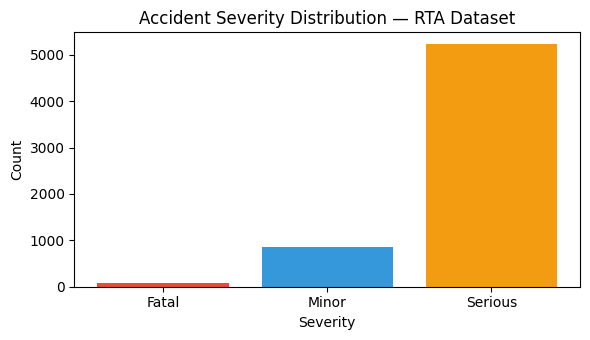

In [10]:
label_map = {0:'Fatal', 1:'Minor', 2:'Serious'}

plt.figure(figsize=(6, 3.5))
counts = df['Accident_severity'].value_counts().sort_index()
plt.bar([label_map.get(i, i) for i in counts.index],
        counts.values, color=['#e74c3c','#3498db','#f39c12'])
plt.title('Accident Severity Distribution — RTA Dataset')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

# Scale features so the neural network trains properly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE balances the 3 severity classes so model treats all equally
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Training samples after SMOTE: {X_train_sm.shape[0]}")
print(f"Class counts: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")

Training samples after SMOTE: 12528
Class counts: {np.int64(0): np.int64(4176), np.int64(1): np.int64(4176), np.int64(2): np.int64(4176)}


In [12]:
model = keras.Sequential([
    layers.Input(shape=(X_train_sm.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes: fatal/minor/serious
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067 (15.89 KB)

 Trainable params: 4,067 (15.89 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train_sm, y_train_sm,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=1
)
print("Training complete!")

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5045 - loss: 0.9847 - val_accuracy: 0.2163 - val_loss: 1.0485
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6032 - loss: 0.8248 - val_accuracy: 0.1732 - val_loss: 0.9959
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6531 - loss: 0.7170 - val_accuracy: 0.1971 - val_loss: 0.9174
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6798 - loss: 0.6480 - val_accuracy: 0.3911 - val_loss: 0.8429
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7033 - loss: 0.5938 - val_accuracy: 0.4110 - val_loss: 0.8180
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7128 - loss: 0.5573 - val_accuracy: 0.3551 - val_loss: 0.8140
Epoch 7/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7206 - loss: 0.5327 - val_accuracy: 0.5379 - val_loss: 0.7463
Epoch 8/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7342 - loss: 0.5067 - val_accuracy: 0.

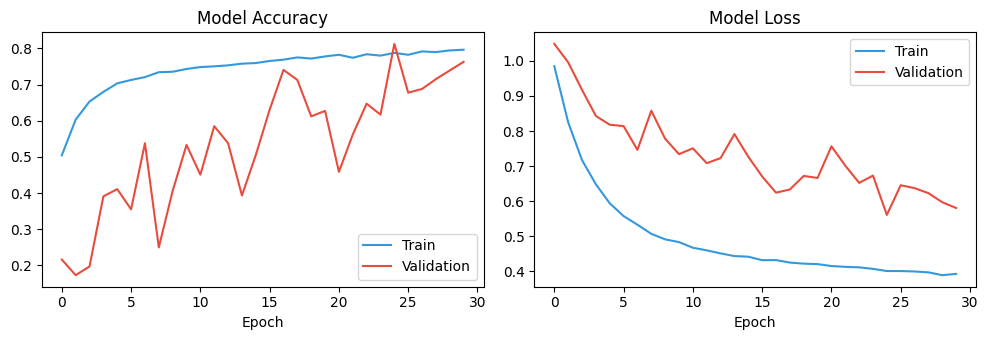

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.plot(history.history['accuracy'], label='Train', color='#3498db')
ax1.plot(history.history['val_accuracy'], label='Validation', color='#e74c3c')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train', color='#3498db')
ax2.plot(history.history['val_loss'], label='Validation', color='#e74c3c')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Classification Report:
                precision    recall  f1-score   support

         Fatal       0.00      0.00      0.00        15
  Minor Injury       0.19      0.46      0.26       171
Serious Injury       0.88      0.67      0.76      1045

      accuracy                           0.63      1231
     macro avg       0.35      0.38      0.34      1231
  weighted avg       0.77      0.63      0.68      1231



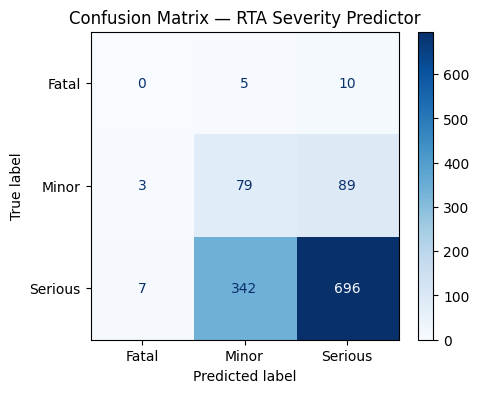

In [15]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fatal', 'Minor Injury', 'Serious Injury']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm,
       display_labels=['Fatal', 'Minor', 'Serious'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix — RTA Severity Predictor')
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
feature_names = list(X.columns)

# Use 150 background samples — fast enough for this small dataset
background = X_train_sm[np.random.choice(
    X_train_sm.shape[0], 150, replace=False)]

explainer = shap.KernelExplainer(model.predict, background)

# Explain 80 test samples
X_test_sample = X_test[:80]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed!")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
  0%|          | 0/80 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
9797/9797 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


  1%|▏         | 1/80 [00:41<54:27, 41.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
9797/9797 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
9797/9797 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step


 99%|█████████▉| 79/80 [33:39<00:35, 35.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
9797/9797 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step


100%|██████████| 80/80 [34:13<00:00, 25.67s/it]

SHAP values computed!


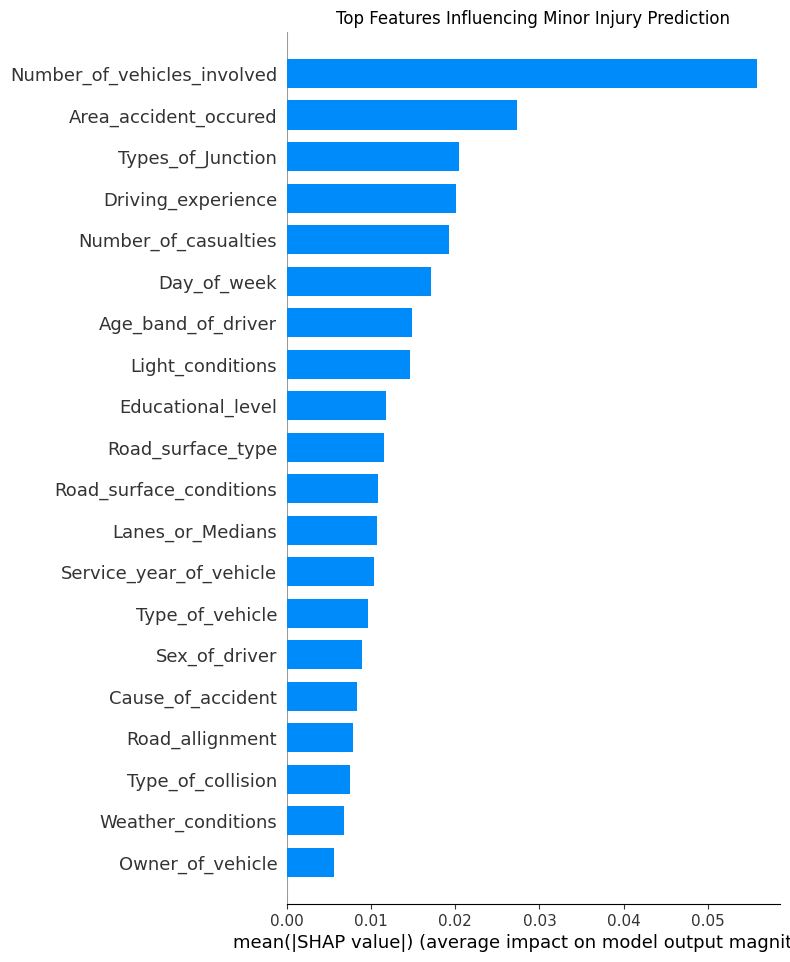

In [18]:
shap.summary_plot(
    shap_values[:, :, 1],   # all samples, all features, class index 1
    X_test_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title('Top Features Influencing Minor Injury Prediction')
plt.savefig('outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


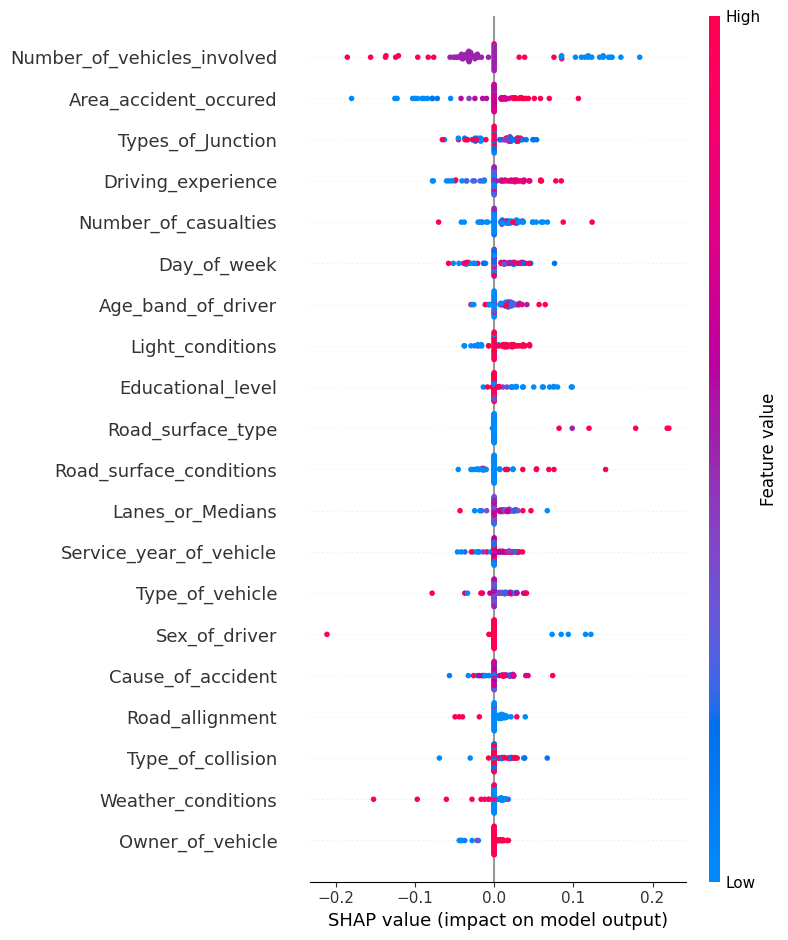

In [20]:
shap.summary_plot(
    shap_values[:, :, 1],   # class index 1 (Minor Injury)
    X_test_sample,
    feature_names=feature_names,
    show=False
)
plt.savefig('outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


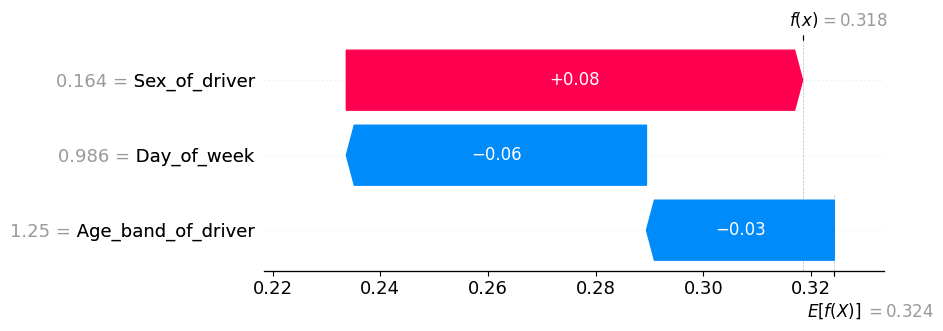

In [21]:
explanation = shap.Explanation(
    values       = shap_values[1][0],
    base_values  = explainer.expected_value[1],
    data         = X_test_sample[0],
    feature_names= feature_names
)
shap.plots.waterfall(explanation, show=False)
plt.savefig('outputs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()